# Australian Tourism Forecasting Demo
EDA and bottom-up hierarchical forecasting on the `tsibble::tourism` dataset.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from tsshowcase.data import aggregate_series, get_series, load_tourism, split_train_test
from tsshowcase.eda import plot_decomposition
from tsshowcase.models import bottom_up_hierarchical, fit_ets, fit_seasonal_naive

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

DATA = Path("../data/tourism.csv")
HORIZON = 8  # 2-year holdout

df = load_tourism(DATA)
train, test = split_train_test(df, test_quarters=HORIZON)

print("Full dataset :", df.shape)
print("Train        :", train.shape, "|", train.index.min(), "–", train.index.max())
print("Test         :", test.shape,  "|", test.index.min(),  "–", test.index.max())
df.head(8)

Full dataset : (24320, 4)
Train        : (21888, 4) | 1998Q1 – 2015Q4
Test         : (2432, 4) | 2016Q1 – 2017Q4


,State,Region,Purpose,Trips
Quarter,,,,
1998Q1,New South Wales,Sydney,Holiday,828.317118
1998Q1,Northern Territory,Alice Springs,Business,7.535107
1998Q1,Northern Territory,Kakadu Arnhem,Business,8.615220
1998Q1,Northern Territory,Katherine Daly,Business,4.976136
1998Q1,Northern Territory,Lasseter,Business,0.522899
1998Q1,Northern Territory,MacDonnell,Business,8.616410
1998Q1,ACT,Canberra,Business,150.198117
1998Q1,New South Wales,Blue Mountains,Visiting friends and relatives,70.542057


**304 leaf series** (76 regions × 4 purposes) over 80 quarters; the last 8 quarters are held out for evaluation.

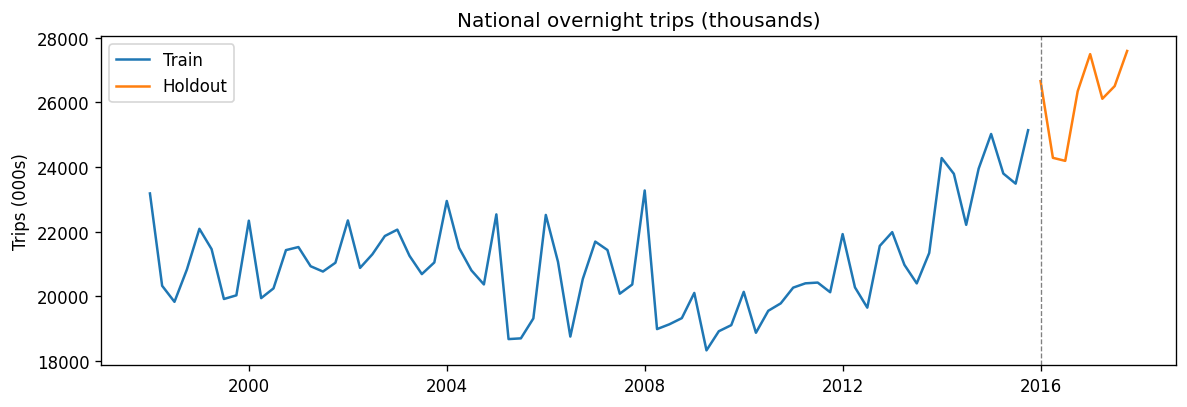

In [2]:
national_train = aggregate_series(train)
national_test  = aggregate_series(test)

train_ts = national_train.copy(); train_ts.index = train_ts.index.to_timestamp()
test_ts  = national_test.copy();  test_ts.index  = test_ts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(train_ts.index, train_ts.values, label="Train")
ax.plot(test_ts.index,  test_ts.values,  label="Holdout", color="tab:orange")
ax.axvline(test_ts.index[0], color="grey", linestyle="--", linewidth=0.8)
ax.set_title("National overnight trips (thousands)")
ax.set_ylabel("Trips (000s)")
ax.legend()
plt.tight_layout()
plt.show()

Total domestic overnight trips grow steadily with a clear quarterly seasonal pattern; the dashed line marks the train/holdout split.

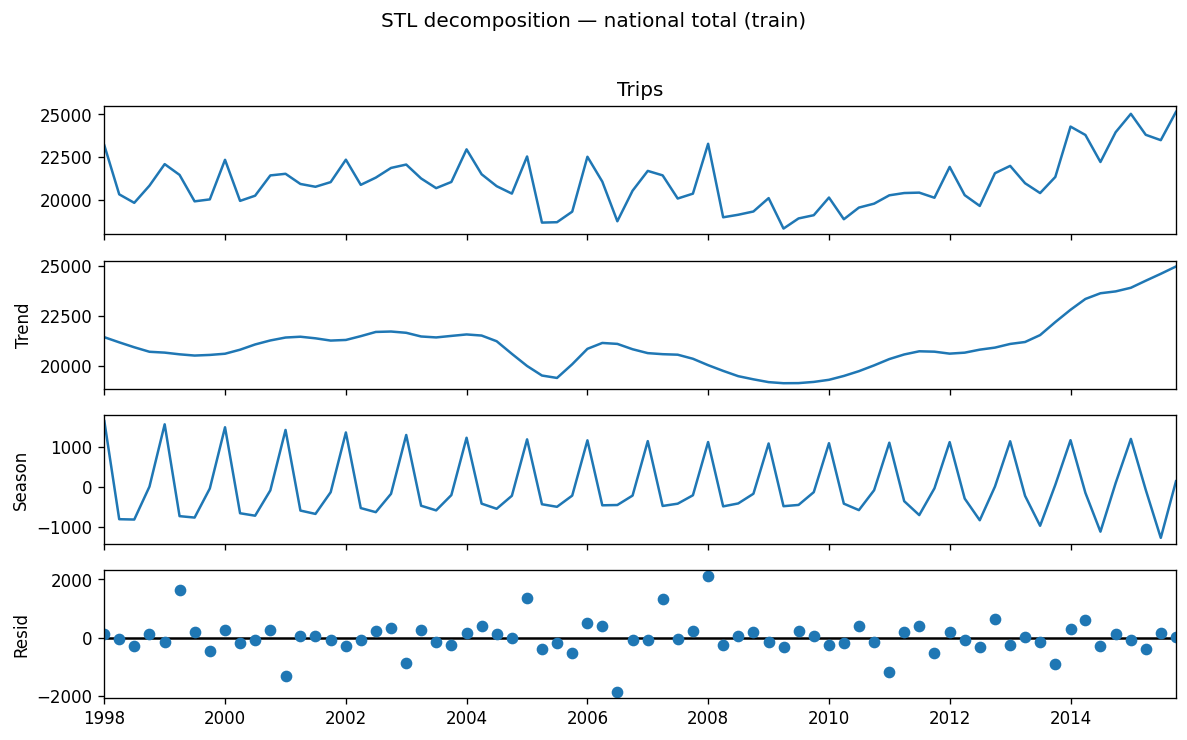

In [3]:
fig = plot_decomposition(
    aggregate_series(train),
    seasonal=13,
    robust=True,
    title="STL decomposition — national total (train)",
)
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()

STL separates a smooth upward trend from a stable Q3-peak seasonal pattern, with small irregular residuals confirming a clean additive structure.

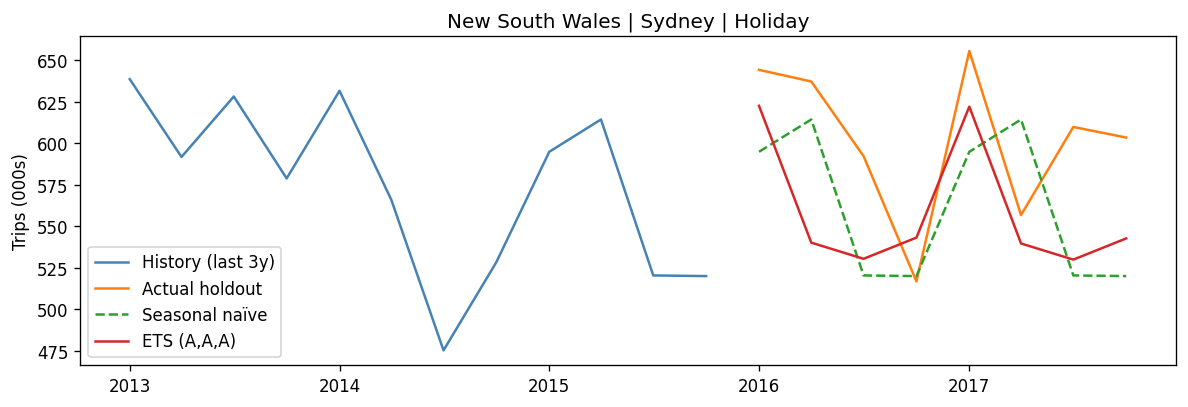

In [4]:
STATE, REGION, PURPOSE = "New South Wales", "Sydney", "Holiday"

leaf_train = get_series(train, STATE, REGION, PURPOSE)
leaf_test  = get_series(test,  STATE, REGION, PURPOSE)

fc_snv = fit_seasonal_naive(leaf_train, HORIZON)
fc_ets = fit_ets(leaf_train, HORIZON)

def _to_ts(s: pd.Series) -> pd.Series:
    s = s.copy(); s.index = s.index.to_timestamp(); return s

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(*(_to_ts(leaf_train.iloc[-12:]).pipe(lambda s: (s.index, s.values))),
        color="steelblue", label="History (last 3y)")
ax.plot(_to_ts(leaf_test).index,  _to_ts(leaf_test).values,  color="tab:orange", label="Actual holdout")
ax.plot(_to_ts(fc_snv).index, _to_ts(fc_snv).values, "--", color="tab:green",  label="Seasonal naïve")
ax.plot(_to_ts(fc_ets).index, _to_ts(fc_ets).values, "-",  color="tab:red",    label="ETS (A,A,A)")
ax.set_title(f"{STATE} | {REGION} | {PURPOSE}")
ax.set_ylabel("Trips (000s)")
ax.legend()
plt.tight_layout()
plt.show()

ETS captures the upward trend and tracks the holdout more closely than seasonal-naïve, which simply repeats the last observed cycle flat.

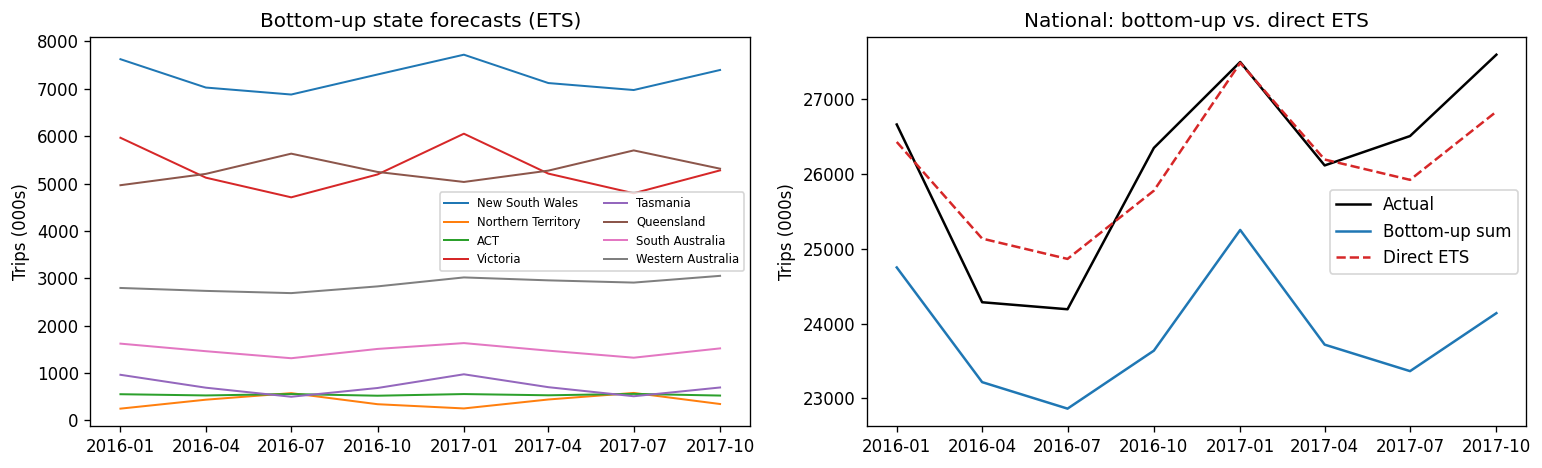

Coherence check — max deviation: 0.00e+00


In [5]:
# Bottom-up: forecast every leaf independently, then sum within each State
bu_state    = bottom_up_hierarchical(train, group_col="State", horizon=HORIZON, fit_fn=fit_ets)
bu_national = bu_state.sum(axis=1)

# Direct: ETS on the national aggregate
direct_national = fit_ets(aggregate_series(train), HORIZON)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — state-level forecasts
ax = axes[0]
for col in bu_state.columns:
    s = _to_ts(bu_state[col])
    ax.plot(s.index, s.values, linewidth=1.2, label=col)
ax.set_title("Bottom-up state forecasts (ETS)")
ax.set_ylabel("Trips (000s)")
ax.legend(fontsize=7, ncol=2)

# Right — coherence: bottom-up national sum vs. direct ETS vs. actual
ax = axes[1]
ax.plot(_to_ts(national_test).index,   _to_ts(national_test).values,   color="black",    label="Actual")
ax.plot(_to_ts(bu_national).index,     _to_ts(bu_national).values,     color="tab:blue", label="Bottom-up sum")
ax.plot(_to_ts(direct_national).index, _to_ts(direct_national).values, "--",
        color="tab:red", label="Direct ETS")
ax.set_title("National: bottom-up vs. direct ETS")
ax.set_ylabel("Trips (000s)")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Coherence check — max deviation: {abs(bu_national - bu_state.sum(axis=1)).max():.2e}")

The bottom-up national total (sum of 8 state ETS forecasts) is coherent by construction and tracks the holdout comparably to a direct ETS on the aggregate — without losing sub-national detail.